# Notebook 08 - Noise Analysis on ECG Signals

## Objective
Analyze the impact of noise on ECG signals and on R-peak detection / BPM estimation.

## Scope
This notebook performs:
- ECG loading
- clean signal visualization
- synthetic noise generation
- baseline wander simulation
- powerline interference simulation
- white Gaussian noise simulation
- comparison of noisy signals
- R-peak detection on clean vs noisy ECG
- BPM comparison
- summary of robustness


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

## 1. File paths

In [2]:
X_path = '../data/processed/cnn_X.npy'
fs = 200  # Hz

print('X exists:', os.path.exists(X_path))

X exists: True


In [3]:
if not os.path.exists(X_path):
    raise FileNotFoundError(f'File not found: {X_path}')

X = np.load(X_path)
print('Original X shape:', X.shape)
print('X dtype:', X.dtype)

Original X shape: (23005, 3600)
X dtype: float32


## 2. Select one ECG signal

In [4]:
if X.ndim == 1:
    ecg_signal = X
elif X.ndim == 2:
    ecg_signal = X[0]
elif X.ndim == 3:
    ecg_signal = X[0, :, 0]
else:
    raise ValueError(f'Unsupported X shape: {X.shape}')

ecg_signal = np.asarray(ecg_signal).astype(float)
t = np.arange(len(ecg_signal)) / fs
duration = len(ecg_signal) / fs

print('Selected ECG shape:', ecg_signal.shape)
print(f'Duration: {duration:.2f} s')

Selected ECG shape: (3600,)
Duration: 18.00 s


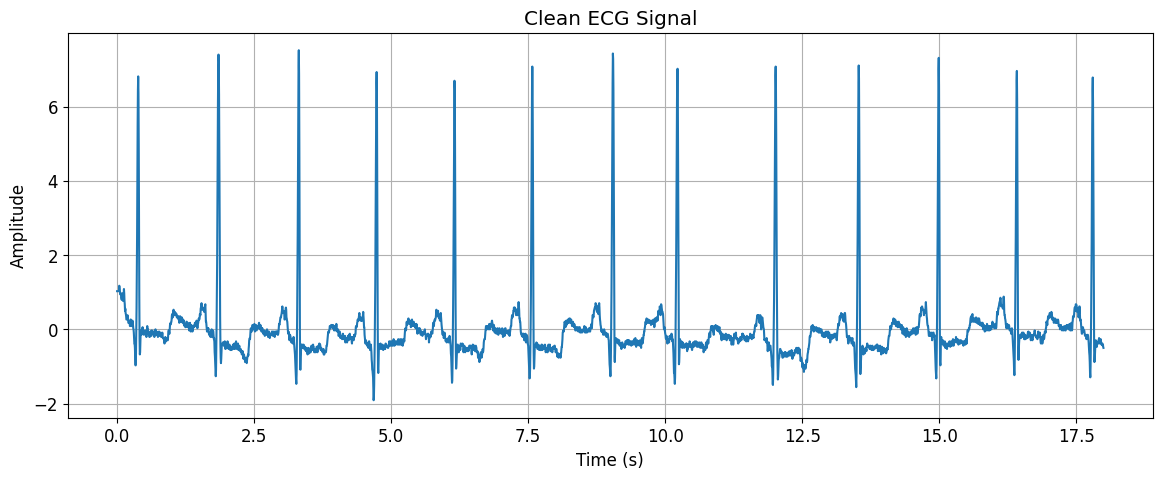

In [5]:
plt.figure()
plt.plot(t, ecg_signal)
plt.title('Clean ECG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## 3. Classical preprocessing and R-peak detection functions

In [6]:
def bandpass_filter(signal, lowcut=5, highcut=15, fs=200, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def detect_r_peaks(signal, fs=200):
    filtered = bandpass_filter(signal, lowcut=5, highcut=15, fs=fs, order=2)
    derivative = np.gradient(filtered)
    squared = derivative ** 2

    window_ms = 150
    window_samples = max(int((window_ms / 1000) * fs), 1)
    kernel = np.ones(window_samples) / window_samples
    integrated = np.convolve(squared, kernel, mode='same')

    threshold = np.mean(integrated) + 0.5 * np.std(integrated)
    min_distance_samples = int(0.3 * fs)

    peaks, properties = find_peaks(
        integrated,
        height=threshold,
        distance=min_distance_samples
    )

    return {
        'filtered': filtered,
        'derivative': derivative,
        'squared': squared,
        'integrated': integrated,
        'threshold': threshold,
        'peaks': peaks
    }

def estimate_bpm(peaks, fs=200):
    if len(peaks) < 2:
        return 0.0
    rr_intervals_s = np.diff(peaks) / fs
    bpm = np.mean(60 / rr_intervals_s)
    return bpm

## 4. Detect peaks on clean signal

In [7]:
clean_result = detect_r_peaks(ecg_signal, fs=fs)
clean_peaks = clean_result['peaks']
clean_bpm = estimate_bpm(clean_peaks, fs=fs)

print(f'Clean signal peaks: {len(clean_peaks)}')
print(f'Clean signal BPM: {clean_bpm:.2f}')

Clean signal peaks: 13
Clean signal BPM: 41.69


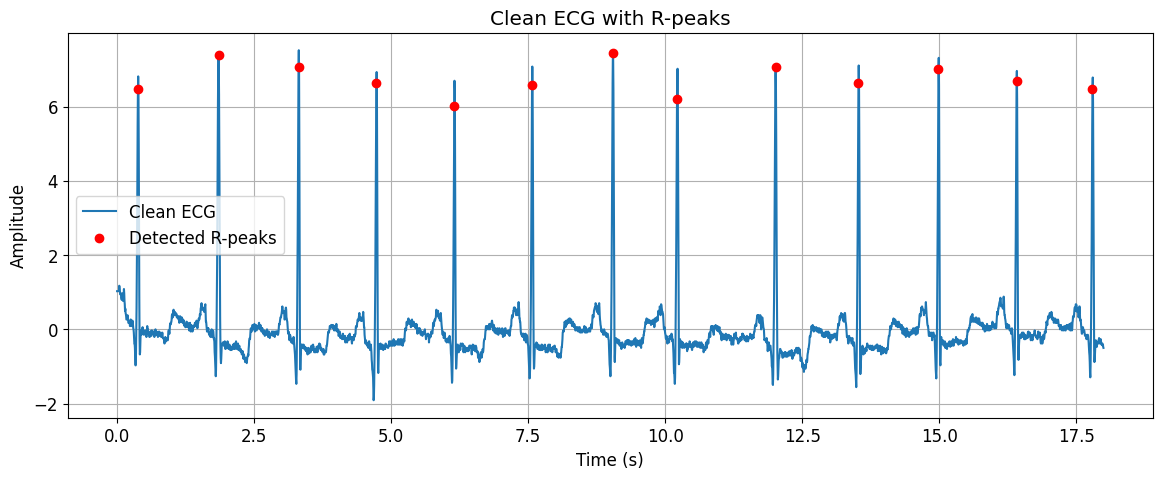

In [8]:
plt.figure()
plt.plot(t, ecg_signal, label='Clean ECG')
plt.plot(t[clean_peaks], ecg_signal[clean_peaks], 'ro', label='Detected R-peaks')
plt.title('Clean ECG with R-peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

## 5. Generate synthetic noises

In [9]:
np.random.seed(42)

# Baseline wander (low frequency)
baseline_wander = 0.2 * np.sin(2 * np.pi * 0.3 * t)

# Powerline interference (50 Hz)
powerline_noise = 0.05 * np.sin(2 * np.pi * 50 * t)

# White Gaussian noise
gaussian_noise = 0.10 * np.std(ecg_signal) * np.random.randn(len(ecg_signal))

print('Synthetic noises generated successfully.')

Synthetic noises generated successfully.


## 6. Create noisy signals

In [10]:
ecg_baseline = ecg_signal + baseline_wander
ecg_powerline = ecg_signal + powerline_noise
ecg_gaussian = ecg_signal + gaussian_noise
ecg_combined = ecg_signal + baseline_wander + powerline_noise + gaussian_noise

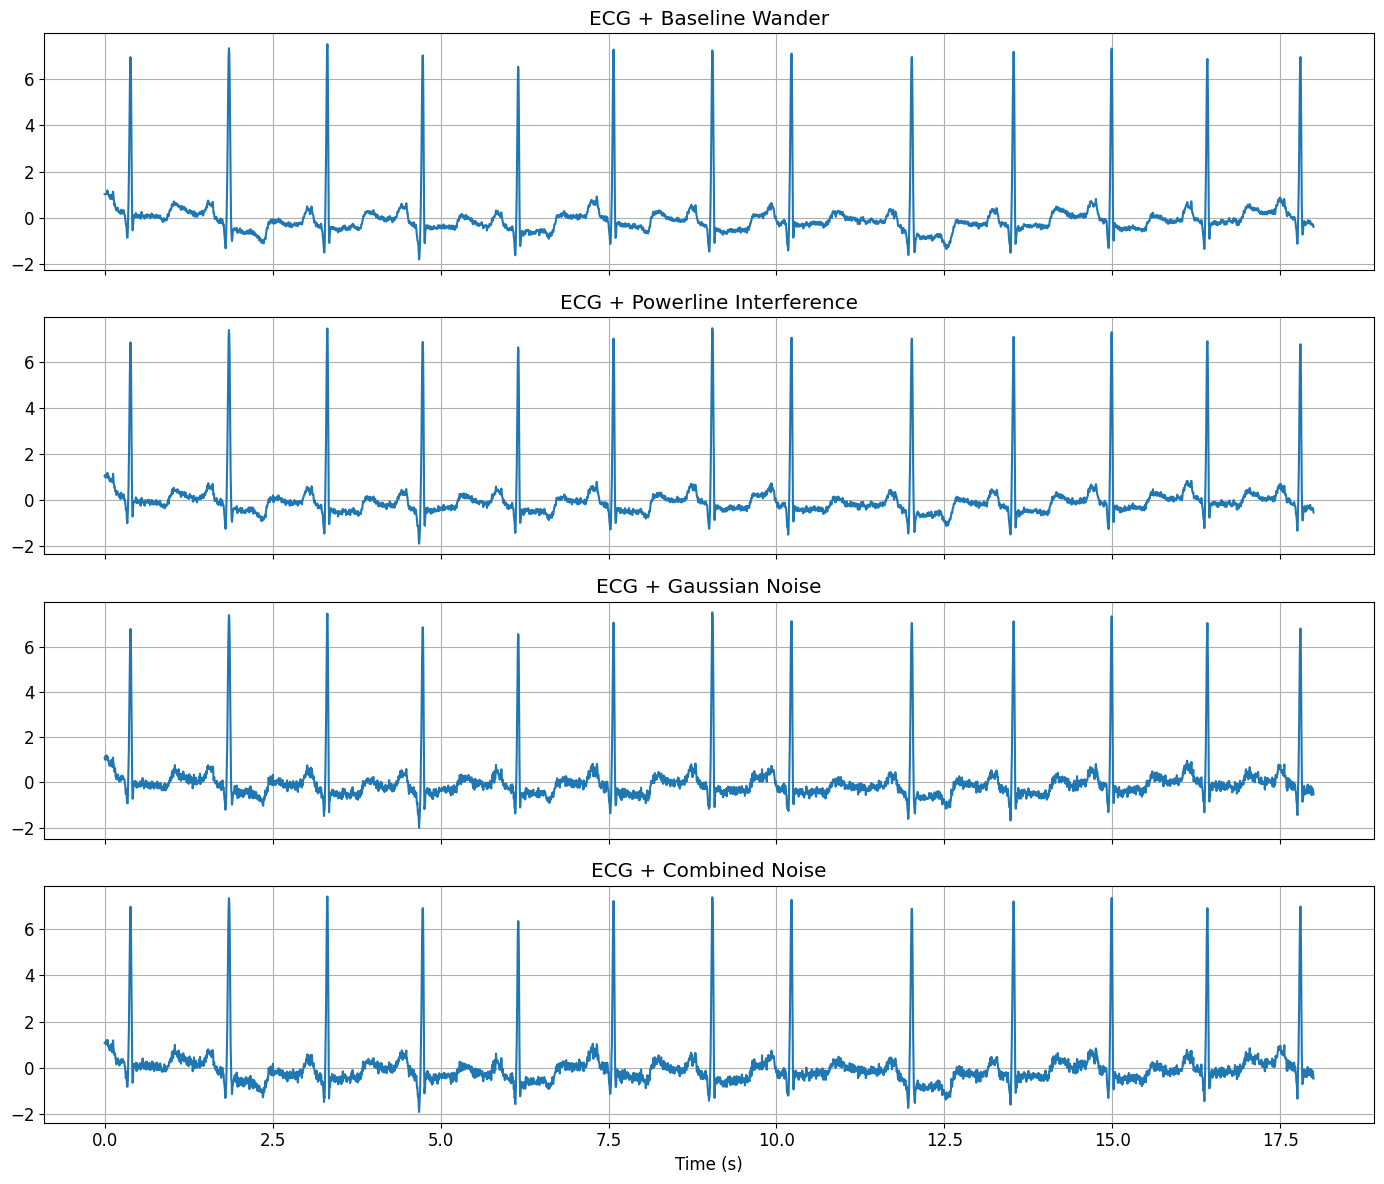

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t, ecg_baseline)
axes[0].set_title('ECG + Baseline Wander')
axes[0].grid(True)

axes[1].plot(t, ecg_powerline)
axes[1].set_title('ECG + Powerline Interference')
axes[1].grid(True)

axes[2].plot(t, ecg_gaussian)
axes[2].set_title('ECG + Gaussian Noise')
axes[2].grid(True)

axes[3].plot(t, ecg_combined)
axes[3].set_title('ECG + Combined Noise')
axes[3].grid(True)
axes[3].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

## 7. Peak detection on noisy signals

In [12]:
baseline_result = detect_r_peaks(ecg_baseline, fs=fs)
powerline_result = detect_r_peaks(ecg_powerline, fs=fs)
gaussian_result = detect_r_peaks(ecg_gaussian, fs=fs)
combined_result = detect_r_peaks(ecg_combined, fs=fs)

baseline_bpm = estimate_bpm(baseline_result['peaks'], fs=fs)
powerline_bpm = estimate_bpm(powerline_result['peaks'], fs=fs)
gaussian_bpm = estimate_bpm(gaussian_result['peaks'], fs=fs)
combined_bpm = estimate_bpm(combined_result['peaks'], fs=fs)

print('Baseline peaks:', len(baseline_result['peaks']), '| BPM:', round(baseline_bpm, 2))
print('Powerline peaks:', len(powerline_result['peaks']), '| BPM:', round(powerline_bpm, 2))
print('Gaussian peaks:', len(gaussian_result['peaks']), '| BPM:', round(gaussian_bpm, 2))
print('Combined peaks:', len(combined_result['peaks']), '| BPM:', round(combined_bpm, 2))

Baseline peaks: 13 | BPM: 41.69
Powerline peaks: 13 | BPM: 41.69
Gaussian peaks: 13 | BPM: 41.69
Combined peaks: 13 | BPM: 41.69


## 8. Compare integrated signal and detected peaks

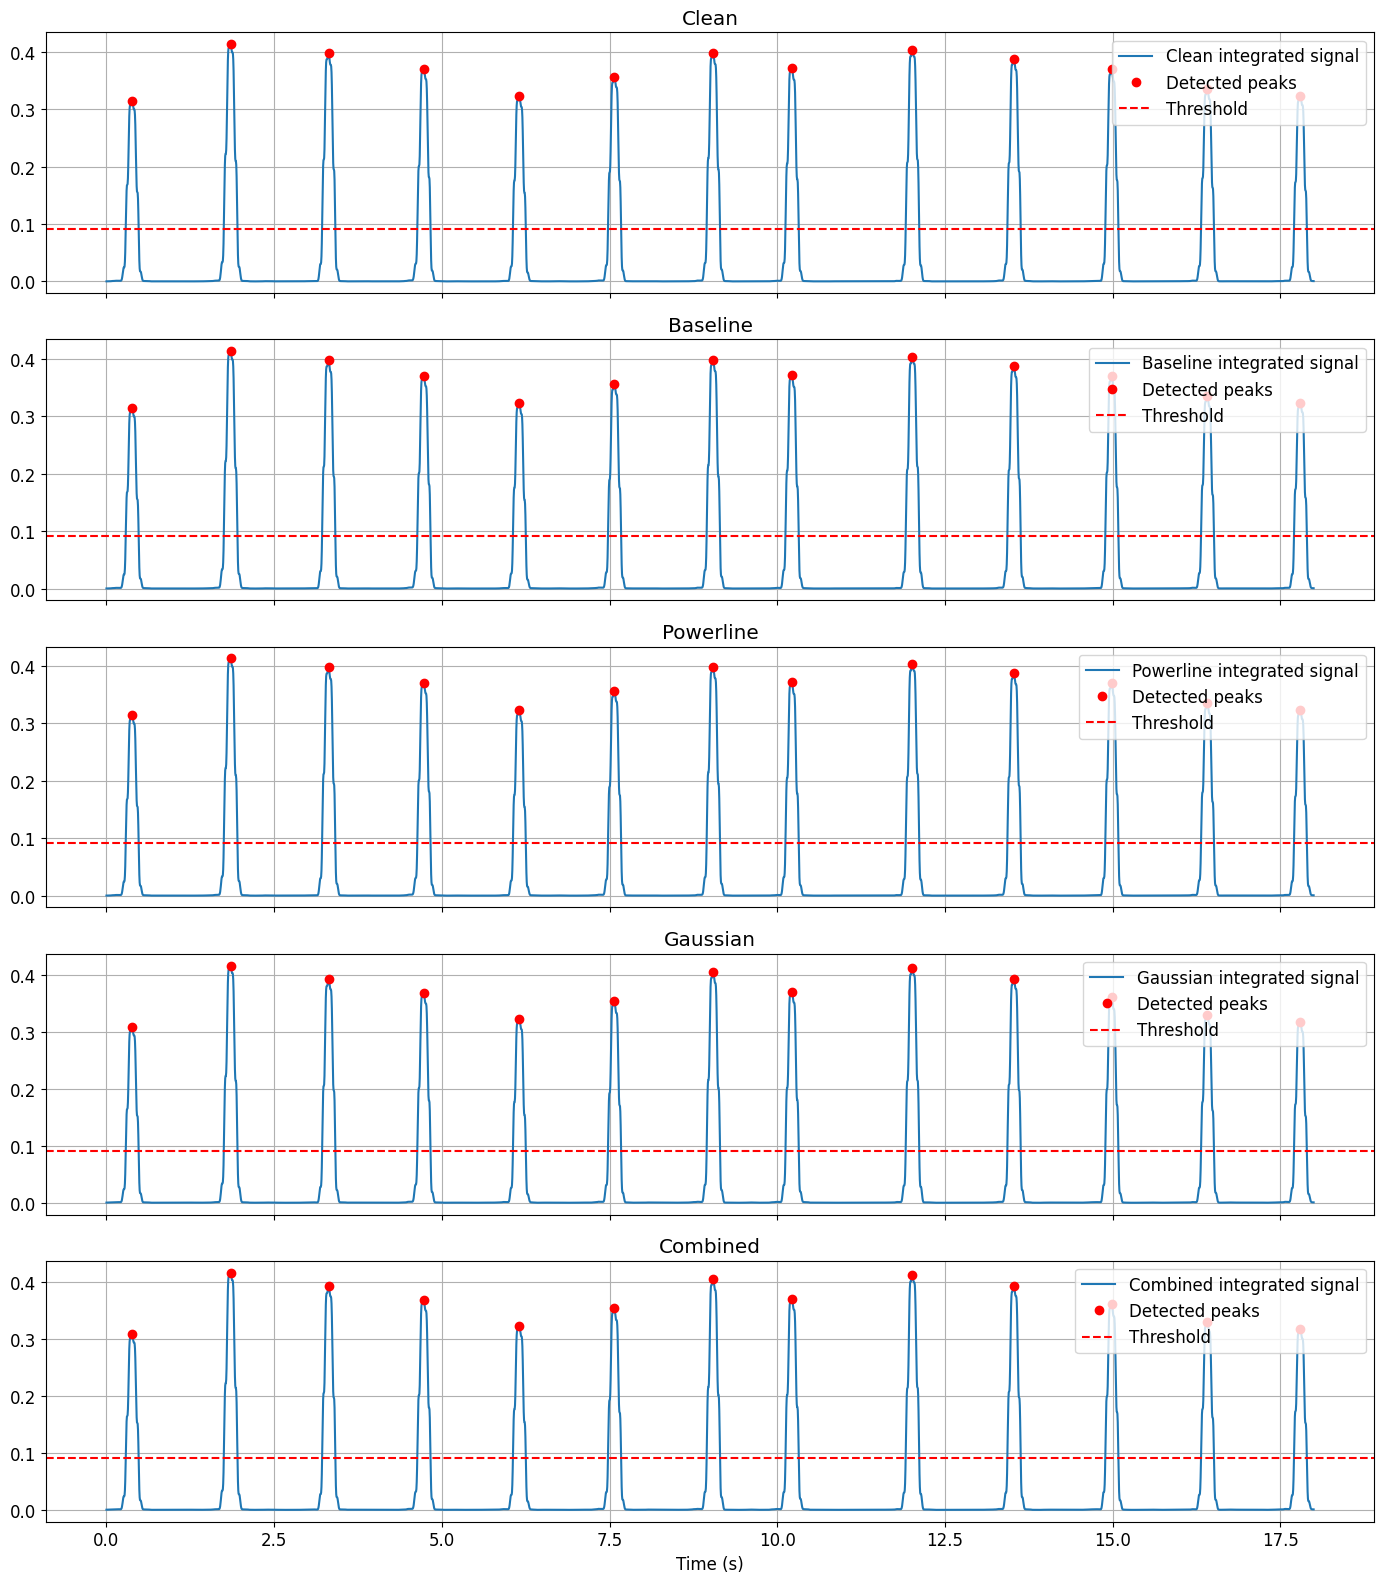

In [13]:
results_dict = {
    'Clean': clean_result,
    'Baseline': baseline_result,
    'Powerline': powerline_result,
    'Gaussian': gaussian_result,
    'Combined': combined_result
}

fig, axes = plt.subplots(len(results_dict), 1, figsize=(14, 16), sharex=True)

for ax, (name, res) in zip(axes, results_dict.items()):
    peaks = res['peaks']
    ax.plot(t, res['integrated'], label=f'{name} integrated signal')
    ax.plot(t[peaks], res['integrated'][peaks], 'ro', label='Detected peaks')
    ax.axhline(res['threshold'], color='red', linestyle='--', label='Threshold')
    ax.set_title(name)
    ax.grid(True)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## 9. Zoom comparison on the first seconds

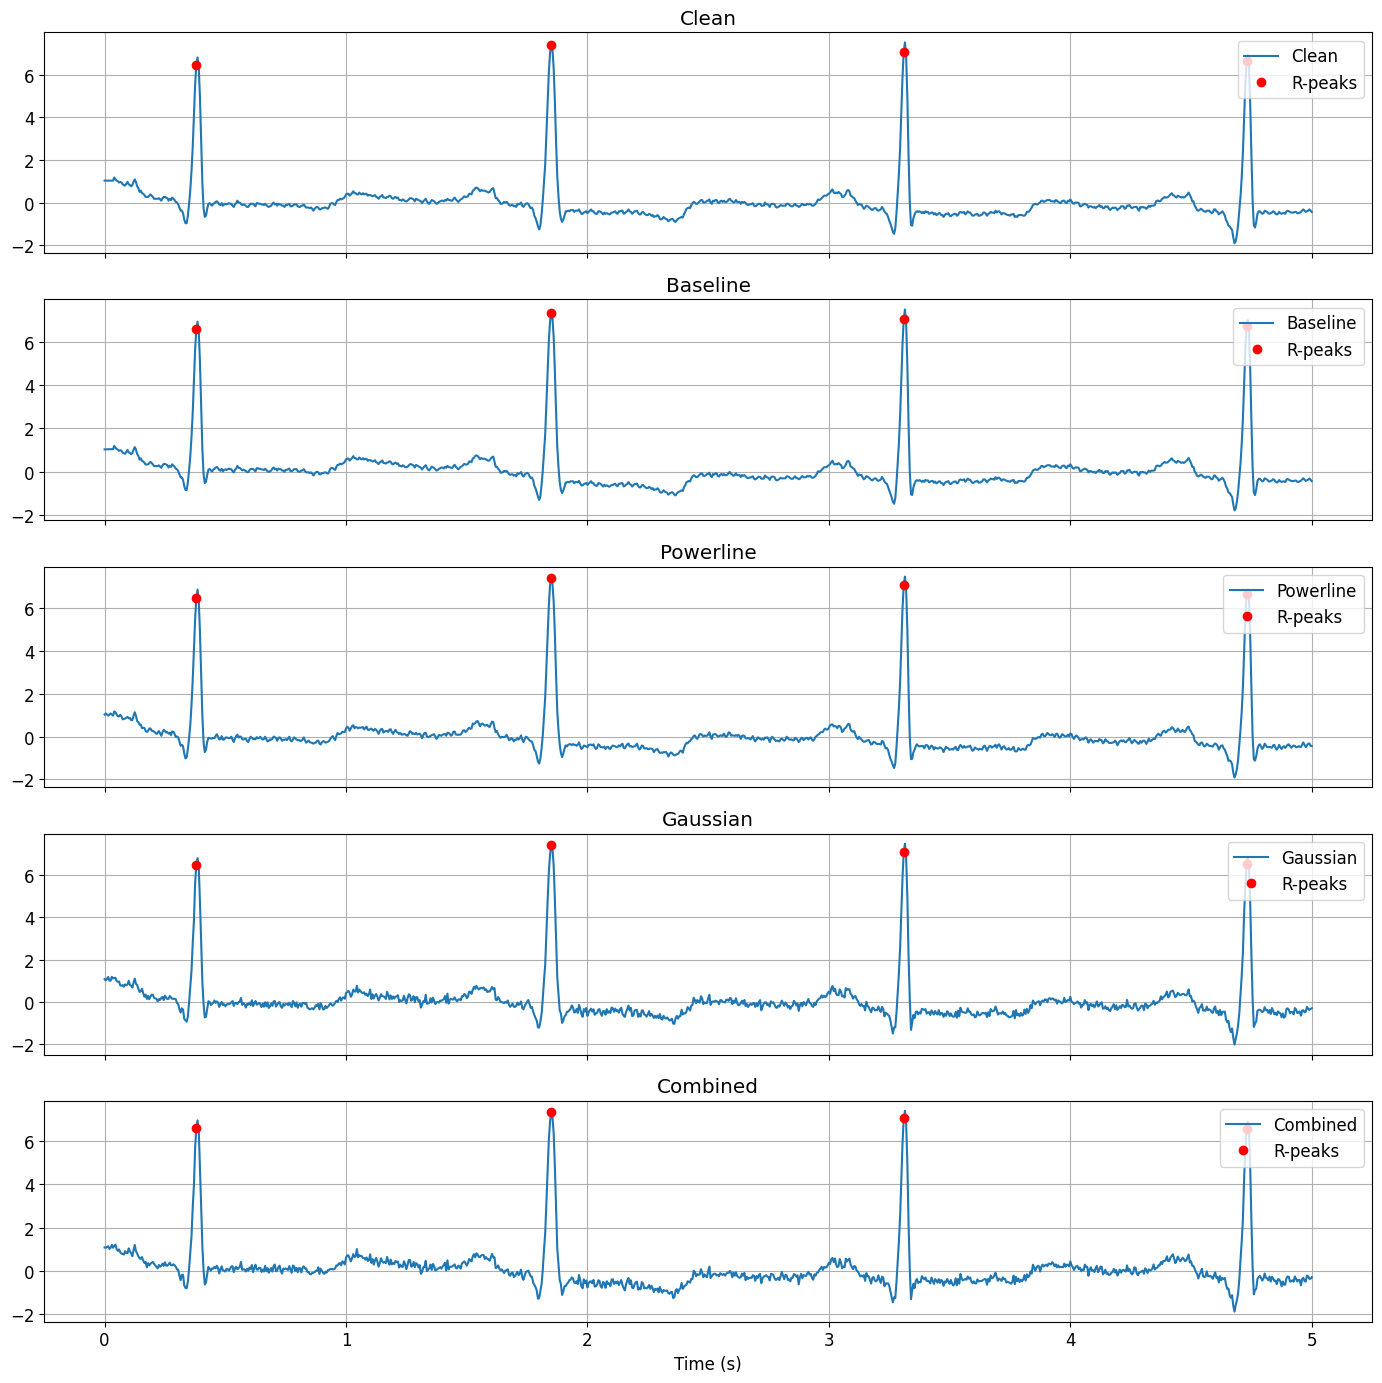

In [14]:
zoom_seconds = min(5, duration)
mask = t <= zoom_seconds

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

signals_dict = {
    'Clean': (ecg_signal, clean_result['peaks']),
    'Baseline': (ecg_baseline, baseline_result['peaks']),
    'Powerline': (ecg_powerline, powerline_result['peaks']),
    'Gaussian': (ecg_gaussian, gaussian_result['peaks']),
    'Combined': (ecg_combined, combined_result['peaks'])
}

for ax, (name, (signal, peaks)) in zip(axes, signals_dict.items()):
    local_peak_mask = t[peaks] <= zoom_seconds
    ax.plot(t[mask], signal[mask], label=name)
    ax.plot(t[peaks][local_peak_mask], signal[peaks][local_peak_mask], 'ro', label='R-peaks')
    ax.set_title(name)
    ax.grid(True)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## 10. BPM robustness summary

In [15]:
summary = pd.DataFrame({
    'Condition': ['Clean', 'Baseline Wander', 'Powerline', 'Gaussian', 'Combined'],
    'Detected Peaks': [
        len(clean_result['peaks']),
        len(baseline_result['peaks']),
        len(powerline_result['peaks']),
        len(gaussian_result['peaks']),
        len(combined_result['peaks'])
    ],
    'Estimated BPM': [
        clean_bpm,
        baseline_bpm,
        powerline_bpm,
        gaussian_bpm,
        combined_bpm
    ],
    'BPM Error vs Clean': [
        0,
        baseline_bpm - clean_bpm,
        powerline_bpm - clean_bpm,
        gaussian_bpm - clean_bpm,
        combined_bpm - clean_bpm
    ]
})
summary

,Condition,Detected Peaks,Estimated BPM,BPM Error vs Clean
0,Clean,13,41.685307,0.000000
1,Baseline Wander,13,41.685307,0.000000
2,Powerline,13,41.685307,0.000000
3,Gaussian,13,41.685394,0.000087
4,Combined,13,41.685394,0.000087


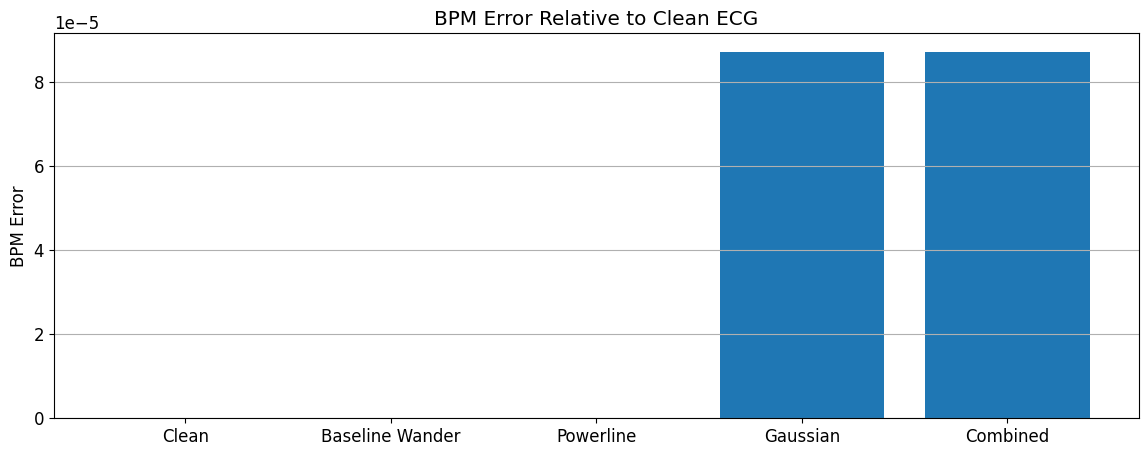

In [16]:
plt.figure()
plt.bar(summary['Condition'], summary['BPM Error vs Clean'])
plt.title('BPM Error Relative to Clean ECG')
plt.ylabel('BPM Error')
plt.grid(True, axis='y')
plt.show()

## 11. Save summary

In [17]:
os.makedirs('../reports', exist_ok=True)
summary.to_csv('../reports/ecg_noise_analysis_summary.csv', index=False)
print('Saved summary to ../reports/ecg_noise_analysis_summary.csv')

Saved summary to ../reports/ecg_noise_analysis_summary.csv


In [18]:
print('Notebook 08 - Noise Analysis completed successfully.')
print('Generated outputs:')
print('- clean vs noisy ECG comparison')
print('- R-peak detection under noise')
print('- BPM robustness analysis')
print('- summary report saved in ../reports/')

Notebook 08 - Noise Analysis completed successfully.
Generated outputs:
- clean vs noisy ECG comparison
- R-peak detection under noise
- BPM robustness analysis
- summary report saved in ../reports/
